In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brianleung2020/eeg-motor-movementimagery-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eeg-motor-movementimagery-dataset' dataset.
Path to dataset files: /kaggle/input/eeg-motor-movementimagery-dataset


In [ ]:

!pip install mne
!pip install seaborn

In [ ]:
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

path = kagglehub.dataset_download("brianleung2020/eeg-motor-movementimagery-dataset")
print(" Path to dataset:", path)

Using Colab cache for faster access to the 'eeg-motor-movementimagery-dataset' dataset.
 Path to dataset: /kaggle/input/eeg-motor-movementimagery-dataset


In [ ]:

dataset_path = Path(path)
edf_files = list(dataset_path.rglob("*.edf"))

print(f"Znaleziono {len(edf_files)} plików EEG")
print(f"Przykładowy plik: {edf_files[0].name}")

Znaleziono 1526 plików EEG
Przykładowy plik: S025R07.edf


In [ ]:

raw = mne.io.read_raw_edf(edf_files[0], preload=True, verbose=False)

print("Podstawowe informacje:")
print(f"Częstotliwość próbkowania: {raw.info['sfreq']} Hz")
print(f"Liczba kanałów: {len(raw.ch_names)}")
print(f"Kanały: {', '.join(raw.ch_names[:10])}...")
print(f"Czas trwania: {raw.times[-1]:.1f} sek ({raw.times[-1]/60:.1f} min)")

Podstawowe informacje:
Częstotliwość próbkowania: 160.0 Hz
Liczba kanałów: 64
Kanały: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.....
Czas trwania: 123.0 sek (2.0 min)


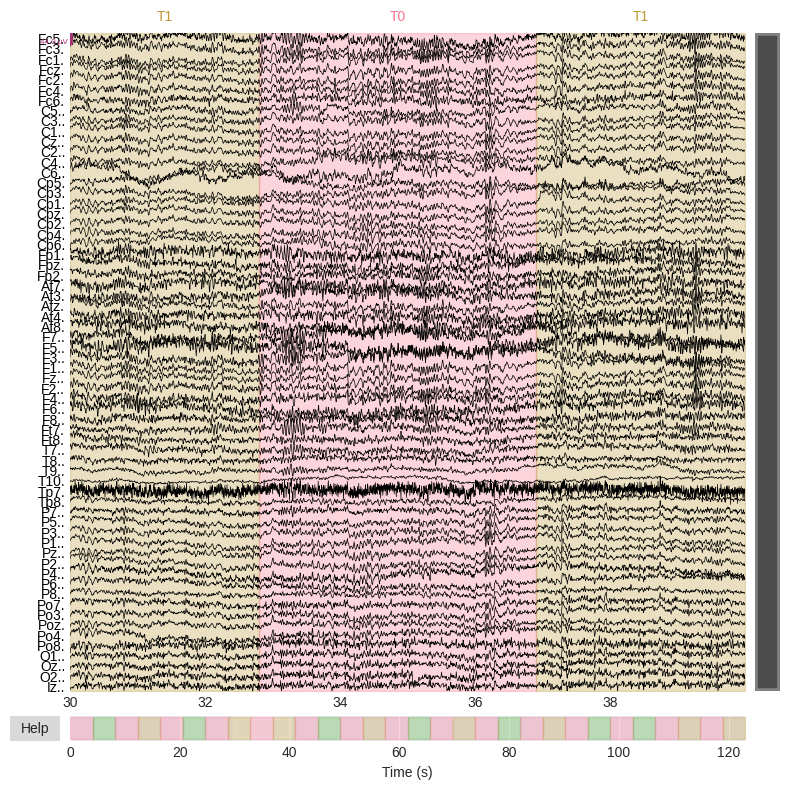

In [ ]:

fig = raw.plot(duration=10, start=30, n_channels=len(raw.ch_names),
               scalings='auto', title='Surowy sygnał EEG (10 sekund)',
               show=False)
plt.tight_layout()
plt.show()

In [ ]:


print("Analiza struktury danych")

if raw.annotations is not None and len(raw.annotations) > 0:
    print(f"Znaleziono {len(raw.annotations)} annotacji")
    print("\nPrzykładowe annotacje:")
    for i in range(min(10, len(raw.annotations))):
        print(f"  {raw.annotations[i]}")


    events, event_id = mne.events_from_annotations(raw, verbose=False)

    print(f"\nUtworzono {len(events)} eventów")
    print(f"Znalezione typy eventów: {event_id}")

else:
    print("Brak annotacji w tym pliku")
    print(f"Kanały: {raw.ch_names}")

    # Szukanie kanału ze znacznikami (często nazywa się 'STI' lub 'Status')
    stim_channels = [ch for ch in raw.ch_names if 'STI' in ch.upper() or 'STATUS' in ch.upper() or 'TRIGGER' in ch.upper()]

    if stim_channels:
        print(f"\nZnaleziono kanał ze znacznikami: {stim_channels[0]}")
        events = mne.find_events(raw, stim_channel=stim_channels[0], verbose=False)
        print(f"Utworzono {len(events)} eventów")

        # Ręczne mapowanie (na podstawie dokumentacji PhysioNet EEG Motor Movement/Imagery)
        event_id = {
            'T0': 1,
            'T1': 2,
            'T2': 3,
            'T3': 4,
            'T4': 5
        }
    else:
        print("\nNie znaleziono kanału ze znacznikami")
        print("Ten plik może nie zawierać eventów lub wymaga innego podejścia")


        print("\nTworzenie syntetycznych eventów dla demonstracji")
        n_events = 20
        event_samples = np.linspace(int(raw.info['sfreq']*10),
                                   int(len(raw.times) - raw.info['sfreq']*10),
                                   n_events, dtype=int)
        event_types = np.random.randint(1, 6, n_events)
        events = np.column_stack([event_samples, np.zeros(n_events, dtype=int), event_types])

        event_id = {
            'T0': 1,
            'T1': 2,
            'T2': 3,
            'T3': 4,
            'T4': 5
        }



event_dict = {
    1: 'Rest (T0)',
    2: 'Left Fist (T1)',
    3: 'Right Fist (T2)',
    4: 'Both Fists (T3)',
    5: 'Both Feet (T4)'
}


if isinstance(event_id, dict) and isinstance(list(event_id.keys())[0], str):
    event_dict_display = {v: k for k, v in event_id.items()}
else:
    event_dict_display = event_dict

print("\n Zadania mnoter imagery")

unique_events = np.unique(events[:, 2])
for event_id_num in unique_events:
    count = np.sum(events[:, 2] == event_id_num)
    name = event_dict_display.get(event_id_num, event_dict.get(event_id_num, f'Unknown {event_id_num}'))
    print(f"{name}: {count} prób")

Analiza struktury danych
Znaleziono 30 annotacji

Przykładowe annotacje:
  OrderedDict({'onset': np.float64(0.0), 'duration': np.float64(4.1), 'description': np.str_('T0'), 'orig_time': datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.timezone.utc), 'extras': {}})
  OrderedDict({'onset': np.float64(4.1), 'duration': np.float64(4.1), 'description': np.str_('T2'), 'orig_time': datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.timezone.utc), 'extras': {}})
  OrderedDict({'onset': np.float64(8.2), 'duration': np.float64(4.1), 'description': np.str_('T0'), 'orig_time': datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.timezone.utc), 'extras': {}})
  OrderedDict({'onset': np.float64(12.3), 'duration': np.float64(4.1), 'description': np.str_('T1'), 'orig_time': datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.timezone.utc), 'extras': {}})
  OrderedDict({'onset': np.float64(16.4), 'duration': np.float64(4.1), 'description': np.str_('T0'), 'orig_time': datetime.datetime(20

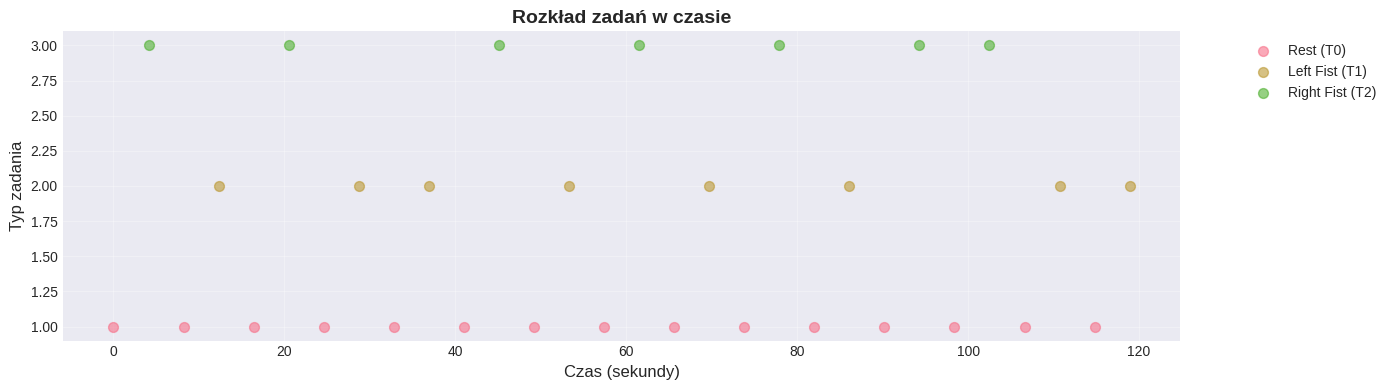

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

for event_id in unique_events:
    mask = events[:, 2] == event_id
    times = events[mask, 0] / raw.info['sfreq']
    ax.scatter(times, [event_id] * len(times),
               label=event_dict.get(event_id, f'Event {event_id}'),
               alpha=0.6, s=50)

ax.set_xlabel('Czas (sekundy)', fontsize=12)
ax.set_ylabel('Typ zadania', fontsize=12)
ax.set_title('Rozkład zadań w czasie', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

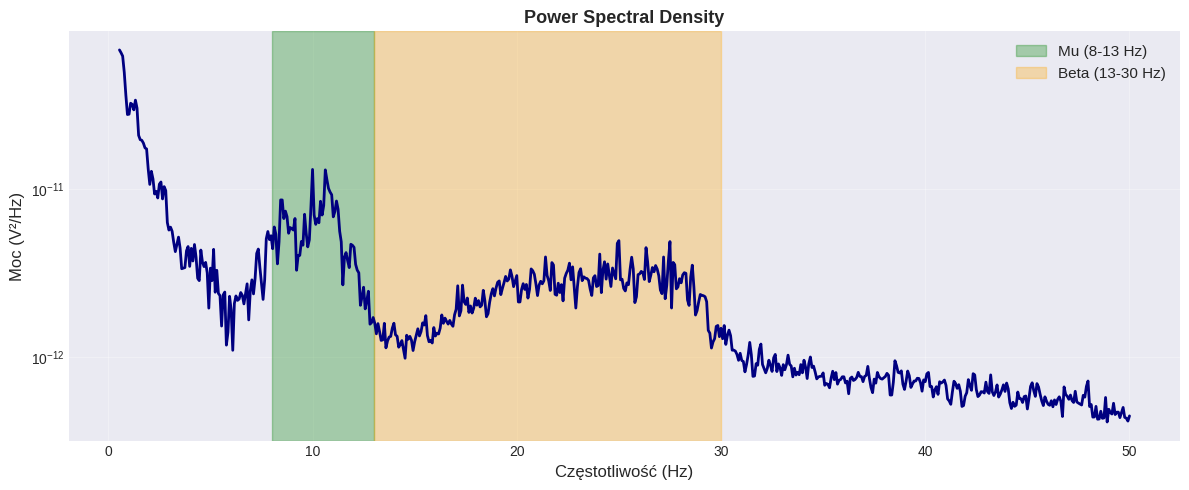

In [ ]:

spectrum = raw.compute_psd(fmin=0.5, fmax=50, n_fft=2048, verbose=False)
psds, freqs = spectrum.get_data(return_freqs=True)
psds_mean = psds.mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(freqs, psds_mean, linewidth=2, color='navy')

bands = {
    'Mu (8-13 Hz)': (8, 13, 'green'),
    'Beta (13-30 Hz)': (13, 30, 'orange')
}

for band_name, (low, high, color) in bands.items():
    ax.axvspan(low, high, alpha=0.3, color=color, label=band_name)

ax.set_xlabel('Częstotliwość (Hz)', fontsize=12)
ax.set_ylabel('Moc (V²/Hz)', fontsize=12)
ax.set_title('Power Spectral Density',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:

tmin, tmax = -1.0, 4.0
event_id = {v: k for k, v in event_dict.items() if k in unique_events}

epochs = mne.Epochs(raw, events, event_id=event_id, tmin=tmin, tmax=tmax,
                    baseline=(tmin, 0), preload=True, verbose=False)

print("Epoki")
print(f"Utworzono {len(epochs)} epok")
print(f"Długość epoki: {tmax - tmin} sekund\n")

for task_name in event_id.keys():
    n = len(epochs[task_name])
    print(f"{task_name}: {n} epok")

Epoki
Utworzono 29 epok
Długość epoki: 5.0 sekund

Rest (T0): 14 epok
Left Fist (T1): 8 epok
Right Fist (T2): 7 epok


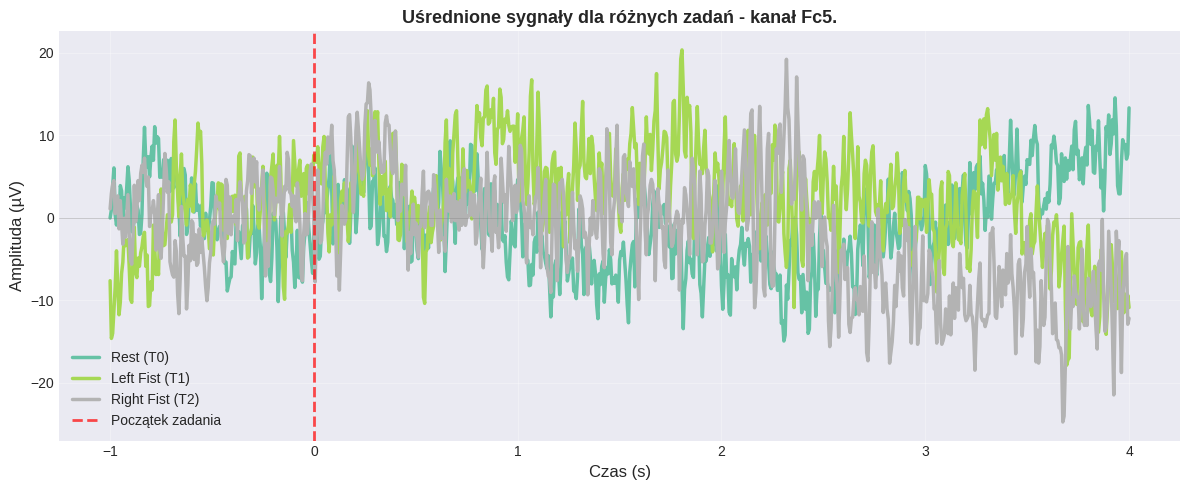

In [ ]:

fig, ax = plt.subplots(figsize=(12, 5))

colors = plt.cm.Set2(np.linspace(0, 1, len(event_id)))


channel = 'C3' if 'C3' in raw.ch_names else raw.ch_names[0]

for (task_name, task_id), color in zip(event_id.items(), colors):
    evoked = epochs[task_name].average()
    if channel in evoked.ch_names:
        ch_idx = evoked.ch_names.index(channel)
        data = evoked.data[ch_idx, :] * 1e6
        ax.plot(evoked.times, data, label=task_name, linewidth=2.5, color=color)

ax.axvline(x=0, color='red', linestyle='--', linewidth=2,
           alpha=0.7, label='Początek zadania')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Czas (s)', fontsize=12)
ax.set_ylabel('Amplituda (µV)', fontsize=12)
ax.set_title(f'Uśrednione sygnały dla różnych zadań - kanał {channel}',
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


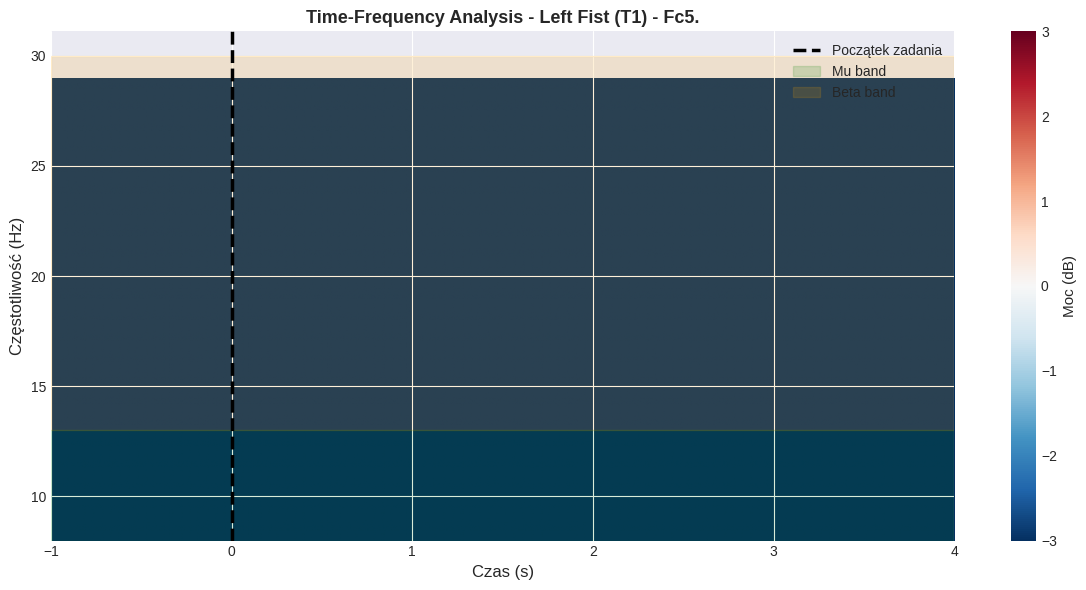

In [ ]:

freqs_tfr = np.arange(8, 30, 1)
n_cycles = freqs_tfr / 2.


task_to_analyze = list(event_id.keys())[1] if len(event_id) > 1 else list(event_id.keys())[0]

power = mne.time_frequency.tfr_morlet(epochs[task_to_analyze], freqs=freqs_tfr,
                                      n_cycles=n_cycles, return_itc=False,
                                      average=True, verbose=False)

channel_tfr = 'C3' if 'C3' in power.ch_names else power.ch_names[0]
ch_idx = power.ch_names.index(channel_tfr)


fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(10 * np.log10(power.data[ch_idx, :, :]),
               extent=[power.times[0], power.times[-1], freqs_tfr[0], freqs_tfr[-1]],
               aspect='auto', origin='lower', cmap='RdBu_r', vmin=-3, vmax=3)

ax.axvline(x=0, color='black', linestyle='--', linewidth=2.5,
           label='Początek zadania')
ax.axhspan(8, 13, alpha=0.15, color='green', label='Mu band')
ax.axhspan(13, 30, alpha=0.15, color='orange', label='Beta band')

ax.set_xlabel('Czas (s)', fontsize=12)
ax.set_ylabel('Częstotliwość (Hz)', fontsize=12)
ax.set_title(f'Time-Frequency Analysis - {task_to_analyze} - {channel_tfr}',
             fontsize=13, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Moc (dB)', fontsize=11)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()
